Intercept: 3793.1819974320533
Coefficient: [110.74976787]
MSE: 3188376687.304782
Prediction: [225292.71774312 169917.83380669]


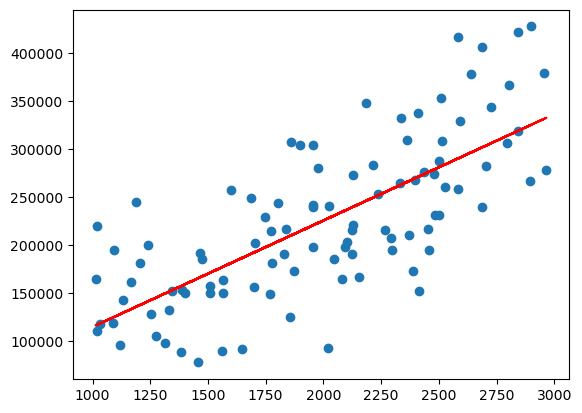

In [1]:
#regression lineaire simple(avec bibliotheque)
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# charger le dataset
df = pd.read_csv("housing_price_dataset.csv")
df = df[:100]
# X = variable indépendantes 
# y = variable dependantes 
X = df[["SquareFeet"]]
y = df["Price"]
# créer et entrainer le modèle de régression linéaire
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)   # predictions on training data

# calculer l'erreur
mse = mean_squared_error(y, y_pred)
# afficher les paramètres du modèle
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)
print("MSE:", mse)
# prédiction pour de nouvelles valeurs
new_df = pd.DataFrame({"SquareFeet": [2000, 1500]})
# appliquer le modele pour prédire les prix
print("Prediction:", model.predict(new_df))

# affichage graphique
# points réels
plt.scatter(X, y) 
# droite de régression
plt.plot(X, y_pred, color='red') 
plt.show()
#alors la fonction de prediction est coefficient*X + Intercept avec X c'est SquareFeet
#99.32210752 * x + 25549.963448873168
#pour la valeur 2000 ->99.32210752 * 2000 + 25549.963448873168=224194.17849859
#pour la valeur 1500 ->99.32210752 * 1500 + 25549.963448873168=174533.12473616

In [21]:
# regression lineaire multiple (avec bibliotheque)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd

# charger le dataset
df = pd.read_csv("housing_price_dataset.csv")

# X = variables independantes 
# y = variable dependantes  
X = df[["SquareFeet", "Bedrooms", "Bathrooms", "YearBuilt"]]
y = df["Price"]

# créer le modèle
model = LinearRegression()

# entrainer le modèle 
model.fit(X, y)

# faire des prédictions sur les données d'entraînement
y_pred = model.predict(X)

# calculer l'erreur 
mse = mean_squared_error(y, y_pred)

# afficher les paramètres du modèle
print("Intercept :", model.intercept_)   
print("Coefficients:", model.coef_)          
print("MSE:", mse)                          

# exemple de nouvelle maison
new_df = pd.DataFrame({
    "SquareFeet": [2000],
    "Bedrooms": [3],
    "Bathrooms": [2],
    "YearBuilt": [2010]
})

# prédiction du prix
print("Prediction:", model.predict(new_df))
#alors la fonction de prediction est c1*X1 + c2*X2 + c3*X3 + c4*X4 +Intercept avec X1,X2,X3,X4 egale a (SquareFeet Bedrooms Bathrooms YearBuilt) respectivement
#99.36140678 * 2000 + 5073.95875505*3 + 2831.33395718*2 + -11.01728775*2010 + 23942.926323084917 = 221405.53567447

Intercept: 23942.926323084917
Coefficient: [  99.36140678 5073.95875505 2831.33395718  -11.01728775]
MSE: 2492476794.556619
Prediction: [221405.53567447]


In [22]:
# regression lineaire polynomiale (avec bibliotheque)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd

# charger le dataset
df = pd.read_csv("housing_price_dataset.csv")

# X = variable independantes 
# y = variable dependantes 
X = df[["SquareFeet"]]
y = df["Price"]

# créer les variables polynomiales 
poly = PolynomialFeatures(degree=2)

# transformer X → [1, x, x²]
X_poly = poly.fit_transform(X)

# créer le modèle de régression linéaire
model = LinearRegression()

# entrainer le modèle sur les données transformées
model.fit(X_poly, y)

# faire des prédictions sur les données d'entraînement
y_pred = model.predict(X_poly)

# calculer l'erreur 
mse = mean_squared_error(y, y_pred)

# afficher les paramètres
print("Intercept:", model.intercept_)   
print("Coefficients:", model.coef_)         
print("MSE:", mse)

# nouvelle valeur
new_df = pd.DataFrame({"SquareFeet": [2000]})

# appliquer la même transformation
new_poly = poly.transform(new_df)

# prédiction
print("Prediction:", model.predict(new_poly))

#c0*X^0 + c1*X + c2*X^2 + intercept
#97.5015862 * X + 0.000454411691 * X^2 + 27222.85396472845
#97.5015862 * 2000 + 0.000454411691 * (2000^2) + 27222.85396472845 = 224043.67317599

Intercept: 27222.85396472845
Coefficient: [0.00000000e+00 9.75015862e+01 4.54411691e-04]
MSE: 2530109882.655531
Prediction: [224043.67317599]


Loss (MSE): 1594688245.828322
Prediction: [225049.17201877]


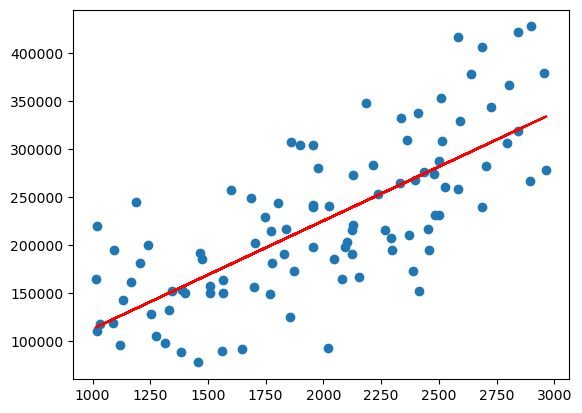

In [1]:
# regression lineaire simple (from scratch)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# charger le dataset
df = pd.read_csv("housing_price_dataset.csv")
df = df[:100]

# X = variable independante 
# y = variable dependante 
X = df["SquareFeet"].values
y = df["Price"].values

def regression_lineaire_simple(X, y, alpha=0.00000001, iterations=1000):
    # initialiser les paramètres
    a = 0.0
    b = 0.0
    m = len(y)

    for i in range(iterations):
        # calcul des prédictions (y = ax + b)
        y_pred = a * X + b
        
        # calcul de l'erreur
        erreur = y_pred - y
        
        # calcul des gradients 
        da = (1/m) * np.sum(erreur * X)
        db = (1/m) * np.sum(erreur)
        
        # mise à jour des paramètres (descente de gradient)
        a -= alpha * da
        b -= alpha * db

        # calcul de l'erreur MSE
        mse = (np.sum(erreur**2)) / (2*m)
        
        # afficher la loss à la dernière itération
        if i == iterations - 1:
            print(f"Loss (MSE): {mse}")

    return a, b

# entrainement
a, b = regression_lineaire_simple(X, y)

# prédiction avec DataFrame
new_df = pd.DataFrame({"SquareFeet": [2000]})
y_pred = a * new_df["SquareFeet"].values + b

print("Prediction:", y_pred)

# affichage graphique
# points réels
plt.scatter(X, y) 
Y_pred = a * X + b
# droite de régression
plt.plot(X, Y_pred, color='red') 
plt.show()
#on a pas la meme valeur que celle de regression lineaire simple avec biblio car en a utiliser la methode d aproximation Gradient Descent 
#la regression lineaire simple avec biblio utulise la methode exacte

In [23]:
# regression lineaire multiple (from scratch)
import numpy as np
import pandas as pd

df = pd.read_csv("housing_price_dataset.csv")

def regression_lineaire_multivariee(X, y, alpha=0.01, iterations=1000):

    m = X.shape[0]  # nombre de lignes 
    
    # ajouter une colonne de 1 pour le biais (intercept)
    colonne_un = np.ones((m, 1))
    X_b = np.hstack((colonne_un, X))
    
    # initialiser les poids à 0 (y = w0 + w1*x1 + w2*x2 + ...)
    W = np.zeros((X_b.shape[1], 1))
    
    for i in range(iterations):
        
        # calcul des prédictions
        y_pred = X_b @ W
        
        # calcul de l'erreur 
        erreur = y_pred - y
        
        # calcul des gradients 
        gradients = (1/m) * (X_b.T @ erreur)
        
        # mise à jour des poids
        W = W - alpha * gradients

        mse=(np.sum(erreur**2))/(2*m)
        if i==999:
            print(f"loss {mse}")
        
    return W
X = df[["SquareFeet", "Bedrooms", "Bathrooms", "YearBuilt"]].values 
y = df["Price"].values.reshape(-1, 1)


theta = regression_lineaire_multivariee(X, y, alpha=0.00000001, iterations=50000)
new_df = pd.DataFrame({ "SquareFeet": [2000],
                         "Bedrooms": [3],
                         "Bathrooms": [2],
                         "YearBuilt": [2010] })

# Ajouter la colonne de 1 pour l'intercept 
new_Xb = np.hstack([np.ones((new_df.shape[0], 1)), new_df.values]) 

# Calcul des prédictions 
y_pred = new_Xb @ theta 
print("Prediction:", y_pred)
#on a pas la meme valeur que celle de regression lineaire simple avec biblio car en a utiliser la methode d aproximation Gradient Descent 
#la regression lineaire simple avec biblio utulise la methode exacte

loss 1276446291.4602728
Prediction: [[224503.09270407]]


In [24]:
# regression lineaire polynomiale (from scratch)
import numpy as np
import pandas as pd

df = pd.read_csv("housing_price_dataset.csv")

X = df["SquareFeet"].values
y = df["Price"].values

def regression_polynomiale(X, y, alpha=0.0000000000000001, iterations=100000):
    
    m = len(y)

    # créer les variables polynomiales (x et x²)
    X_poly = np.c_[np.ones(m), X, X**2]

    # initialiser les paramètres(degree 2)
    w0 = 0.0
    w1 = 0.0
    w2 = 0.0

    for i in range(iterations):

        # calcul des prédictions
        y_pred = w0 + w1 * X + w2 * (X**2)

        # calcul de l'erreur
        erreur = y_pred - y

        # calcul des gradients
        dw0 = (1/m) * np.sum(erreur)
        dw1 = (1/m) * np.sum(erreur * X)
        dw2 = (1/m) * np.sum(erreur * (X**2))

        # mise à jour des paramètres
        w0 -= alpha * dw0
        w1 -= alpha * dw1
        w2 -= alpha * dw2

        mse=(np.sum(erreur**2))/(2*m)
        if i==9999:
            print(f"loss {mse}")
            
    return w0, w1, w2

# training
w0, w1, w2 = regression_polynomiale(X, y)

# prédiction avec DataFrame
new_df = pd.DataFrame({"SquareFeet": [2000]})

x = new_df["SquareFeet"].values
y_pred = w0 + w1 * x + w2 * (x**2)

print("Prediction:", y_pred)

loss 2848694099.452186
Prediction: [182291.54791441]


Iteration 0 | Loss: 0.6931471805599452
Iteration 100 | Loss: 0.6718837642528013
Iteration 200 | Loss: 0.656597963388087
Iteration 300 | Loss: 0.6425510143428173
Iteration 400 | Loss: 0.6295721043343893
Iteration 500 | Loss: 0.6175728223543173
Iteration 600 | Loss: 0.606472263358267
Iteration 700 | Loss: 0.5961956787660568
Iteration 800 | Loss: 0.5866742568199586
Iteration 900 | Loss: 0.5778448469380084
Iteration 1000 | Loss: 0.5696496365274305
Iteration 1100 | Loss: 0.5620358011345639
Iteration 1200 | Loss: 0.5549551438954227
Iteration 1300 | Loss: 0.5483637360858516
Iteration 1400 | Loss: 0.5422215671886467
Iteration 1500 | Loss: 0.5364922102048656
Iteration 1600 | Loss: 0.5311425058466605
Iteration 1700 | Loss: 0.5261422676637931
Iteration 1800 | Loss: 0.5214640089833008
Iteration 1900 | Loss: 0.5170826916981355
Classe prédite (0=pas cher, 1=cher): [1]


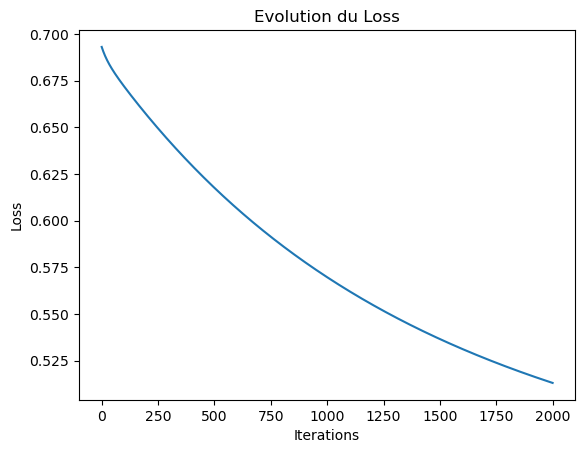

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 1. Charger le dataset

df = pd.read_csv("housing_price_dataset.csv")

#créer une cible binaire
#1 si prix > moyenne, sinon 0
df["HighPrice"] = (df["Price"] > df["Price"].mean()).astype(int)


#Choisir les variables

X = df[["SquareFeet", "Bedrooms", "Bathrooms", "YearBuilt"]].values
y = df["HighPrice"].values


#Classe Regression Logistique

class RegressionLogistique:

    def __init__(self, alpha=0.00000001, n_iters=1000):
        self.alpha = alpha
        self.n_iters = n_iters
        self.W = None
        self.b = None
        self.historique_loss = []

    def _sigmoide(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.W = np.zeros(n_features)
        self.b = 0.0

        for i in range(self.n_iters):
            linear_model = np.dot(X, self.W) + self.b
            y_pred = self._sigmoide(linear_model)

            # éviter log(0)
            y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)

            # loss
            loss = -(1 / n_samples) * np.sum(
                y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred)
            )
            self.historique_loss.append(loss)

            # gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # mise a jour de parametre
            self.W -= self.alpha * dw
            self.b -= self.alpha * db

            if i % 100 == 0:
                print(f"Iteration {i} | Loss: {loss}")

    def predict(self, X):
        z = np.dot(X, self.W) + self.b
        y_pred = self._sigmoide(z)
        return (y_pred >= 0.5).astype(int)



#Entraînement

model = RegressionLogistique(n_iters=2000)
model.fit(X, y)

#Prédiction

new_df = pd.DataFrame({
    "SquareFeet": [2000],
    "Bedrooms": [3],
    "Bathrooms": [2],
    "YearBuilt": [2010]
})

prediction = model.predict(new_df.values)

print("Classe prédite (0=pas cher, 1=cher):", prediction)


#Courbe de loss

plt.plot(model.historique_loss)
plt.title("Evolution du Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()